# MOL518 Final Project  
David Godovich  
5/5/2026


In [ ]:
# I don't use colab but have a fork of the class repo
# Run this to set up colab file structure
# %cd /content
# !rm -rf MOL518-Intro-to-Data-Analysis

# !git clone https://github.com/dgodovich/MOL518-Intro-to-Data-Analysis.git
# %cd MOL518-Intro-to-Data-Analysis/FinalProject

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, spatial, interpolate
from scipy.optimize import curve_fit, linear_sum_assignment
import skimage as ski
from pathlib import Path
from tifffile import imread, imwrite

In [2]:
# helper functions copied from lecture 35 notebook

def make_spot_image(shape, positions, amplitudes=None, sigma=1.8, background=20.0, noise=3.0, rng=None):
    yy, xx = np.mgrid[: shape[0], : shape[1]]
    image = np.full(shape, background, dtype=float)
    if amplitudes is None:
        amplitudes = np.full(len(positions), 180.0)
    for (y0, x0), amp in zip(positions, amplitudes):
        image += amp * np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * sigma**2))
    if rng is not None:
        image += noise * rng.normal(size=shape)
    return np.clip(image, 0, None)


def find_local_maxima(image, min_distance=4, threshold=0.0):
    size = 2 * min_distance + 1
    local_max = ndimage.maximum_filter(image, size=size, mode='reflect')
    peaks = np.argwhere((image == local_max) & (image > threshold))
    return peaks


def centroid_localization(image, y, x, radius=4):
    y_min = max(0, y - radius)
    y_max = min(image.shape[0], y + radius + 1)
    x_min = max(0, x - radius)
    x_max = min(image.shape[1], x + radius + 1)
    window = image[y_min:y_max, x_min:x_max]
    weights = window - np.min(window)
    total_intensity = np.sum(weights)
    if total_intensity <= 0:
        return np.array([float(y), float(x)])
    yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
    y_centroid = np.sum(yy * weights) / total_intensity
    x_centroid = np.sum(xx * weights) / total_intensity
    return np.array([y_centroid, x_centroid])


def gaussian_2d(coords, A, x0, y0, sigma, B):
    x, y = coords
    return A * np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma**2)) + B


def fit_gaussian_2d(image, y, x, radius=5):
    y_min = max(0, y - radius)
    y_max = min(image.shape[0], y + radius + 1)
    x_min = max(0, x - radius)
    x_max = min(image.shape[1], x + radius + 1)
    patch = image[y_min:y_max, x_min:x_max]
    yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
    baseline = float(np.median(patch))
    amplitude = float(np.max(patch) - baseline)
    p0 = (amplitude, float(x), float(y), 2.0, baseline)
    bounds = (
        [0.0, x_min, y_min, 0.5, 0.0],
        [np.inf, x_max, y_max, 6.0, np.inf],
    )
    popt, _ = curve_fit(
        gaussian_2d,
        (xx.ravel(), yy.ravel()),
        patch.ravel(),
        p0=p0,
        bounds=bounds,
        maxfev=2000,
    )
    return {
        'amplitude': popt[0],
        'x': popt[1],
        'y': popt[2],
        'sigma': popt[3],
        'background': popt[4],
        'patch': patch,
        'xx': xx,
        'yy': yy,
    }


def compute_cost_matrix(points_t, points_t1):
    # Compute the cost matrix based on Euclidean distance between points in frame t and t+1.
    cost_matrix = np.zeros((len(points_t), len(points_t1)))
    for i in range(len(points_t)):
        for j in range(len(points_t1)):
            dy = points_t[i, 0] - points_t1[j, 0]
            dx = points_t[i, 1] - points_t1[j, 1]
            cost_matrix[i, j] = np.sqrt(dx**2 + dy**2)
    return cost_matrix

### a
Done mostly without AI

In [3]:
calibration = imread('Biplane_Calibration_80x80x100nm.tif')
calibration.shape

(40, 512, 512)

In [4]:
half_index = calibration.shape[1]//2
top_image = calibration[:,0:half_index,:]
bottom_image = calibration[:,half_index:calibration.shape[1],:]

In [5]:
# found focus planes from visual inspection in fiji
top_focus = 18
bottom_focus = 25

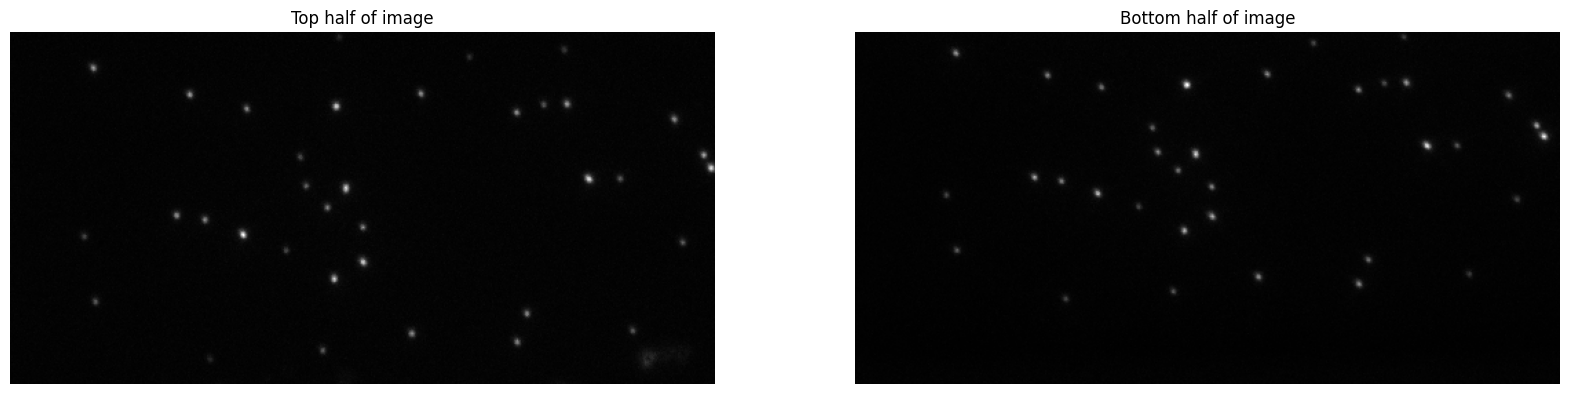

In [6]:
fig, ax = plt.subplots(1,2, figsize = (20,8))
ax[0].imshow(top_image[top_focus], cmap = 'gray')
ax[0].axis('off')
ax[0].set_title('Top half of image')
ax[1].imshow(bottom_image[bottom_focus], cmap = 'gray')
ax[1].axis('off')
ax[1].set_title('Bottom half of image')
plt.show()

There's some shift, but more problematically there is a compression / scale, mostly in y. Affine transform should be able to handle all of that, but might be a bit tricky to get the right scale.

In [7]:
top_use = top_image[top_focus]
bottom_use = bottom_image[bottom_focus]

In [8]:
# some more helper functions
def refine_peaks(image, peaks):
    # get subpixel center localization
    centroids = []
    gaussian_fits = []
    for peak_y, peak_x in peaks:
        centroid_y, centroid_x = centroid_localization(image, peak_y, peak_x, radius=5)
        centroids.append([centroid_y, centroid_x])
        fit_result = fit_gaussian_2d(image, int(peak_y), int(peak_x), radius=5)
        gaussian_fits.append([fit_result['y'], fit_result['x']])

    return centroids, gaussian_fits

def process_alignment(image):
    # run the basic pipeline
    log_filtered = -ndimage.gaussian_laplace(image, sigma=.3) # Laplacian of the Gaussian
    peak_threshold = log_filtered.mean() + 2.8 * log_filtered.std() # Find the threshold of a bright spot - I'm using the same one as in lecture
    max_filtered = ndimage.maximum_filter(log_filtered, size=9, mode='reflect') # Maximum filter to make it easier to find the peak
    peaks = find_local_maxima(log_filtered, min_distance=4, threshold=peak_threshold)
    centroids, gaussian_fits = refine_peaks(image, peaks) # find subpixel location

    # get everything back for plotting / debugging
    return {
        'log_filtered': log_filtered,
        'peak_threshold': peak_threshold,
        'max_filtered': max_filtered,
        'peaks': peaks,
        'centroids': centroids,
        'gaussian_fits': gaussian_fits,
    } 

In [9]:
top_peaks = process_alignment(top_use)
bottom_peaks = process_alignment(bottom_use)

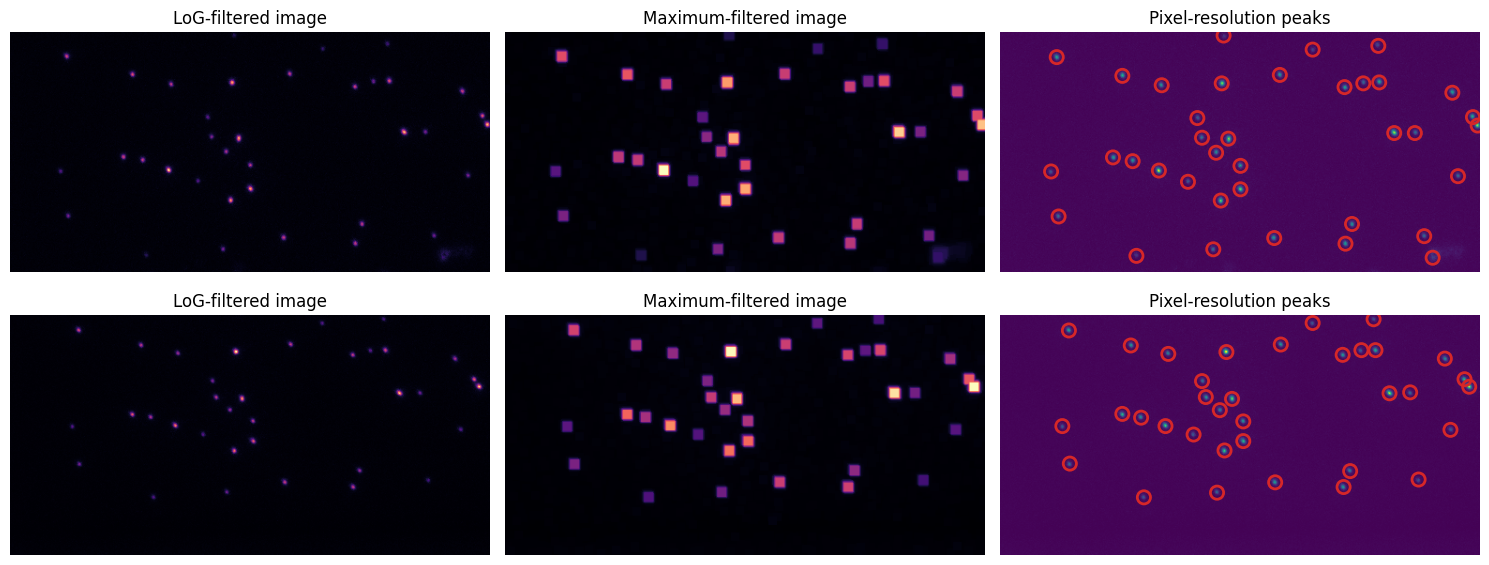

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes[0][0].imshow(top_peaks['log_filtered'], cmap='magma')
axes[0][0].set_title('LoG-filtered image')
axes[0][0].axis('off')

axes[0][1].imshow(top_peaks['max_filtered'], cmap='magma')
axes[0][1].set_title('Maximum-filtered image')
axes[0][1].axis('off')

axes[0][2].imshow(top_use)
axes[0][2].scatter(top_peaks['peaks'][:, 1], top_peaks['peaks'][:, 0], s=90, facecolors='none', edgecolors='C3', linewidths=2)
axes[0][2].set_title('Pixel-resolution peaks')
axes[0][2].axis('off')

axes[1][0].imshow(bottom_peaks['log_filtered'], cmap='magma')
axes[1][0].set_title('LoG-filtered image')
axes[1][0].axis('off')

axes[1][1].imshow(bottom_peaks['max_filtered'], cmap='magma')
axes[1][1].set_title('Maximum-filtered image')
axes[1][1].axis('off')

axes[1][2].imshow(bottom_use)
axes[1][2].scatter(bottom_peaks['peaks'][:, 1], bottom_peaks['peaks'][:, 0], s=90, facecolors='none', edgecolors='C3', linewidths=2)
axes[1][2].set_title('Pixel-resolution peaks')
axes[1][2].axis('off')

plt.tight_layout()
# print('Detected peaks (row, col):')
# print(peaks)

There's two peaks that are in the top image that aren't in the bottom image - one all the way at the top, and one all the way at the bottom. Since these are close to the edge, I will ignore them. Conveniently, it's the first and last peak, so I can remove them by simple manual indexing

In [11]:
top_peaks_array = np.asarray(top_peaks['gaussian_fits'][1:-1])
bot_peaks_array = np.asarray(bottom_peaks['gaussian_fits'])

In [12]:
# Goal is to use ski.transform.AffineTransform.from_estimate, but it's important that the points are in the correct order
# Use Hungarian method / Euclidean cost matrix to find correct order of points

cost_matrix = compute_cost_matrix(top_peaks_array, bot_peaks_array)
row_ind, col_ind = linear_sum_assignment(cost_matrix)

In [13]:
# I needed a bit of help from Claude for this - I couldn't figure out why it was shifting in the x direction and not in the y direction
# Turns out skimage expects (x,y) and my points were saved as (y,x), so just need to change the order to get it to work

src_xy = top_peaks_array[row_ind][:, ::-1]      # top beads as (x, y)
dst_xy = bot_peaks_array[col_ind][:, ::-1]      # bottom beads as (x, y)
hungarian_tform = ski.transform.AffineTransform.from_estimate(src_xy, dst_xy)

In [14]:
hungarian_tform

<AffineTransform(matrix=
    [[ 9.52790103e-01, -1.41411648e-03,  1.51964233e+01],
     [-1.56188011e-03,  8.44831327e-01, -6.78129740e+00],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]) at 0x7c951437e7b0>

In [15]:
# check displacemennt of the transformed points from the target points
src_warped = ski.transform.matrix_transform(src_xy, hungarian_tform.params)
residuals = np.sqrt(((src_warped - dst_xy)**2).sum(axis=1))

In [16]:
tf_img_top = ski.transform.warp(top_use, hungarian_tform.inverse)

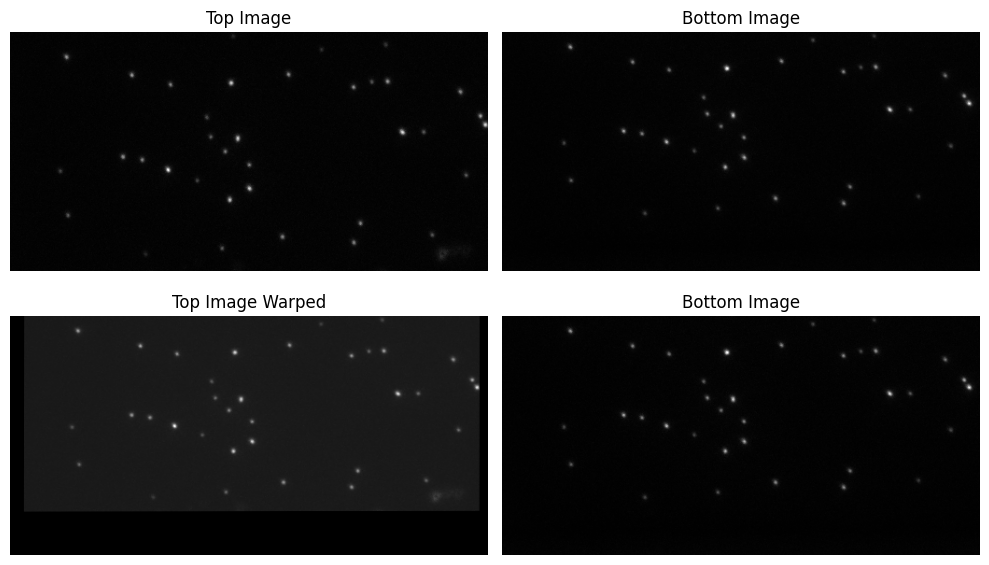

In [17]:
fig, axes = plt.subplots(2,2, figsize = (10,6))
axes[0][0].imshow(top_use, cmap = 'gray')
axes[0][0].set_title("Top Image")
axes[0][1].imshow(bottom_use, cmap = 'gray')
axes[0][1].set_title("Bottom Image")

axes[1][0].imshow(tf_img_top, cmap = 'gray')
axes[1][0].set_title("Top Image Warped")
axes[1][1].imshow(bottom_use, cmap = 'gray')
axes[1][1].set_title("Bottom Image")

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

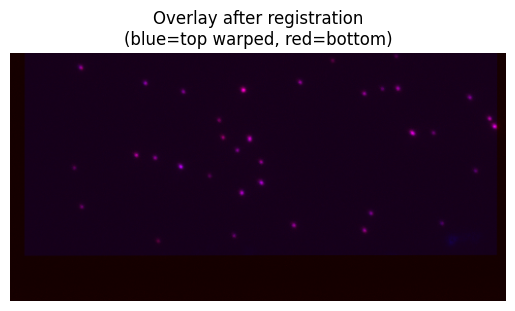

In [18]:
# Idea for how to overlay from Claude
# purple points are overlapping beads, showing that the affine transform is successful
fig, ax = plt.subplots()
rgb = np.zeros((*bottom_use.shape, 3))
rgb[..., 2] = np.clip(tf_img_top/tf_img_top.max(),0,1)
rgb[..., 0] = np.clip(bottom_use/bottom_use.max(),0,1)
ax.imshow(rgb)
ax.set_title('Overlay after registration\n(blue=top warped, red=bottom)')
ax.axis('off')
plt.show()

In [19]:
# This cell is from Claude, just printing out the residuals and the affine transform information in a nice format
print(f"Residuals : mean={residuals.mean():.3f} px  max={residuals.max():.3f} px")
print(f"\nAffine transform (x, y convention):")
print(f"  Scale       (sx, sy) = ({hungarian_tform.scale[0]:.4f}, {hungarian_tform.scale[1]:.4f})")
print(f"  Rotation             = {np.degrees(hungarian_tform.rotation):.3f}°")
print(f"  Translation (tx, ty) = ({hungarian_tform.translation[0]:.2f}, {hungarian_tform.translation[1]:.2f}) px")

Residuals : mean=0.136 px  max=0.439 px

Affine transform (x, y convention):
  Scale       (sx, sy) = (0.9528, 0.8448)
  Rotation             = -0.094°
  Translation (tx, ty) = (15.20, -6.78) px


In [20]:
hungarian_tform

<AffineTransform(matrix=
    [[ 9.52790103e-01, -1.41411648e-03,  1.51964233e+01],
     [-1.56188011e-03,  8.44831327e-01, -6.78129740e+00],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]) at 0x7c951437e7b0>

## b
Using Claude Sonnet 4.6 Adaptive for everything in B and C

With the registration in hand we now extract intensity-vs-z curves for each
matched bead pair and build the **defocus parameter**

$$\eta(z) = \frac{I_{\text{top}}(z) - I_{\text{bot}}(z)}{I_{\text{top}}(z) + I_{\text{bot}}(z)}$$

which is monotonically decreasing through the biplane window and can be
inverted to recover z from any measured (I_top, I_bot) pair.



DG: This seems reasonable to me? I'm a bit worried that it will fail for spots that are fully in one plane and not the other, but I do not have a better idea

In [21]:
# Claude added imports

import matplotlib.cm as cm
from matplotlib.colors import Normalize
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
from scipy.ndimage import uniform_filter
from skimage.restoration import rolling_ball
from skimage import filters, morphology, measure, segmentation, feature, color

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'font.size': 9})

# Physical constants
DXY_NM = 80.0   # nm per pixel (lateral)
DZ_NM  = 59.0   # nm per calibration slice
DT_MS  = 30.0   # ms per movie frame

In [22]:
# Claude: Bridge cell — defines variables and helpers needed by Parts B and C,
# all derived directly from the student's Part A results.
#
# Convention note: skimage's AffineTransform.from_estimate() was called with
# points in (x, y) = (col, row) order (as src_xy / dst_xy above).
# Everywhere else in this notebook, positions are stored as (y, x) = (row, col).
# top_yx_to_bot_yx() handles the flip transparently so downstream code never
# has to worry about the convention.

def top_yx_to_bot_yx(pts_yx):
    """
    Map (y, x) positions in the top focal plane to (y, x) positions in the
    bottom focal plane using hungarian_tform (fitted in x,y convention).
    Accepts any (N, 2) array of [row, col] coordinates.
    """
    #DG: This is necessary to keep axis consistency. 
    pts_xy  = np.atleast_2d(pts_yx)[:, ::-1]          # (y,x) → (x,y) #DG: Invert order of columns to switch x and y
    bot_xy  = ski.transform.matrix_transform(pts_xy, hungarian_tform.params)
    return bot_xy[:, ::-1]                             # (x,y) → (y,x)

#DG: Same thing the other way too
def bot_yx_to_top_yx(pts_yx):
    pts_xy  = np.atleast_2d(pts_yx)[:, ::-1]   # (y,x) → (x,y)
    top_xy  = ski.transform.matrix_transform(pts_xy, hungarian_tform.inverse.params)
    return top_xy[:, ::-1]                       # (x,y) → (y,x)

# Claude: Matched bead pairs in (y, x) convention — used by Part B intensity extraction
top_matched = top_peaks_array[row_ind]   # Claude: (N, 2)  [y, x]  — top bead centroids #DG: these lines just rename variables, Claude was using something else
bot_matched  = bot_peaks_array[col_ind]  # Claude: (N, 2)  [y, x]  — corresponding bottom centroids

print(f"Matched beads available for calibration: {len(top_matched)}")
print(f"Registration residual  mean={residuals.mean():.3f} px  "
      f"max={residuals.max():.3f} px  ({residuals.mean()*DXY_NM:.1f} nm rms)")

# Claude: Thin wrapper so Part C detection code can call fit_gaussian_subpx(image, y, x, radius)
# and get back (y_centroid, x_centroid, amplitude, sigma) — same interface as before.
def fit_gaussian_subpx(image, y_peak, x_peak, radius=5):
    """Wrapper around fit_gaussian_2d returning (y, x, amplitude, sigma)."""
    try:
        r = fit_gaussian_2d(image, y_peak, x_peak, radius=radius)
        return r['y'], r['x'], r['amplitude'], r['sigma'] #DG: wants a different return structure
    except Exception:
        return float(y_peak), float(x_peak), 0.0, 2.0


Matched beads available for calibration: 35
Registration residual  mean=0.136 px  max=0.439 px  (10.9 nm rms)


### B.1  Extract bead intensity vs. z

In [23]:
# Claude: For each matched bead pair we read out the peak intensity in a small
# window around the bead centre at every z-slice of the calibration stack.
# top_matched / bot_matched are (y, x) arrays produced by Part A.
# bot_pos_from_tform uses the affine transform for consistency — even though
# bot_matched already holds Gaussian-fit positions, using the transform ensures
# perfect pairing if any fit failed at the edges.

WINDOW_RADIUS = 3   # pixels around centroid to max over

def peak_intensity_vs_z(stack, y_pos, x_pos, radius=WINDOW_RADIUS):
    """
    Max pixel value in a (2*radius+1)^2 window around (y_pos, x_pos)
    for every z-slice in *stack*.  Returns a 1-D array of length n_z.
    """
    #DG: get exact x and y pixel values from the subpixel estimates of the peaks 
    y = int(round(y_pos));  x = int(round(x_pos)) 

    #DG: Extract a square around each peak
    y1 = max(0, y - radius);  y2 = min(stack.shape[1], y + radius + 1)
    x1 = max(0, x - radius);  x2 = min(stack.shape[2], x + radius + 1)

    #DG: Take the maximum as you exit
    return stack[:, y1:y2, x1:x2].max(axis=(1, 2))

# Claude: Background: 5th-percentile across all slices and pixels
BG_TOP = float(np.percentile(top_image, 5)) #DG: take 5th percentile as background level for top and bottom (pretty much the same)
BG_BOT = float(np.percentile(bottom_image, 5))
print(f"Background estimates — top: {BG_TOP:.1f},  bottom: {BG_BOT:.1f}")

#DG: z height of each slice in the calibration image
z_nm = np.arange(top_image.shape[0]) * DZ_NM   # (40,) z positions in nm 

N = len(top_matched)
# Claude: Use the transform to locate each bead in the bottom stack
bot_pos_from_tform = top_yx_to_bot_yx(top_matched)   # (N, 2)  (y, x)

#DG: set up empty arrays for data
It_all = np.zeros((N, len(z_nm)), dtype=np.float32)
Ib_all = np.zeros((N, len(z_nm)), dtype=np.float32)

#DG: for each bead, find the top and bottom positions
#DG: then get a list of the intensities in each slice
for i in range(N):
    ty, tx = top_matched[i]
    by, bx = bot_pos_from_tform[i]
    It_all[i] = np.maximum(peak_intensity_vs_z(top_image, ty, tx) - BG_TOP, 1.0)
    Ib_all[i] = np.maximum(peak_intensity_vs_z(bottom_image, by, bx) - BG_BOT, 1.0)

print(f"Intensity curves extracted for {N} beads × {len(z_nm)} z-slices")


Background estimates — top: 104.0,  bottom: 101.0
Intensity curves extracted for 35 beads × 40 z-slices


### B.2  Compute η(z) and fit calibration spline

η peak   : slice 17  z=1003 nm  η=0.620
η trough : slice 25  z=1475 nm  η=-0.780
Calibration window: 1003–1475 nm  (9 slices)
Monotone decreasing? True


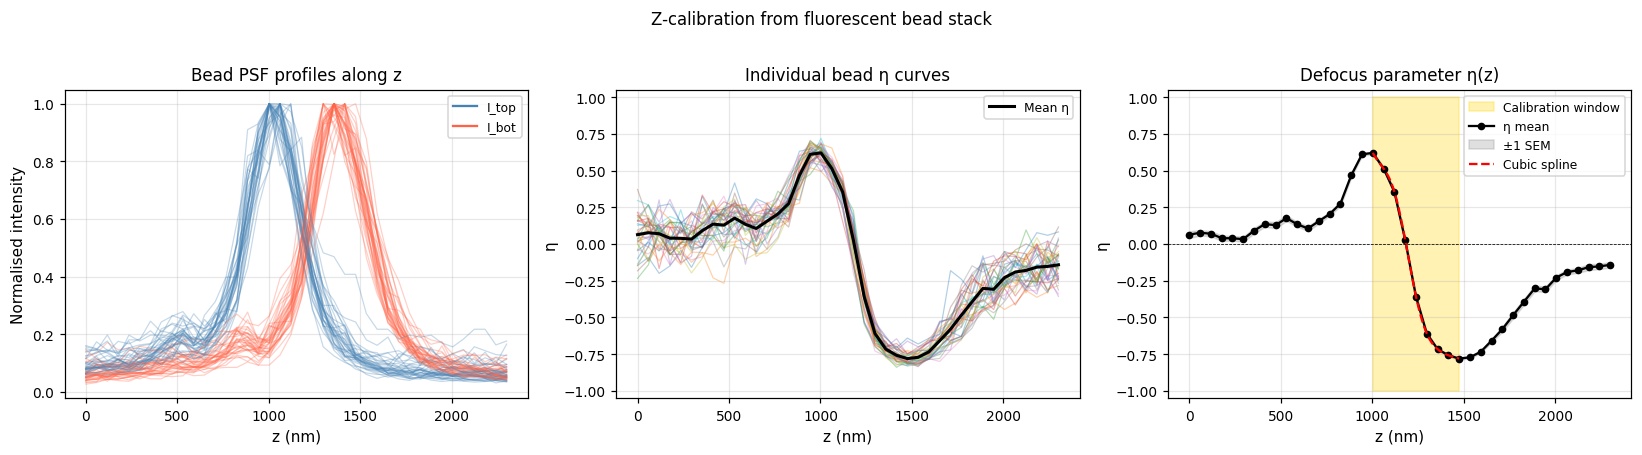

In [24]:
# Claude: Compute the bead-averaged defocus parameter η(z), then identify the
# monotonically decreasing window (top plane in focus → bottom plane in focus)
# which is the only region we can invert.  A cubic spline is fitted to that
# window for sub-slice interpolation.

#DG: calculate the defocus parameter and get some descriptive stats for all spots
eta_all  = (It_all - Ib_all) / (It_all + Ib_all)   # (N, n_z)
eta_mean = eta_all.mean(axis=0)
eta_sem  = eta_all.std(axis=0) / np.sqrt(N)

# Claude: Calibration window: from the η maximum down to the η minimum
#DG: get index of highest and lowest points of the defocus parameter. Use this as bounds for where it is well behaved for curve fitting
peak_idx   = int(np.argmax(eta_mean))
trough_idx = int(np.argmin(eta_mean))

z_calib   = z_nm[peak_idx : trough_idx + 1]
eta_calib = eta_mean[peak_idx : trough_idx + 1]

#DG: print out which slices and Z heights are being used for estimation of eta
print(f"η peak   : slice {peak_idx:2d}  z={z_nm[peak_idx]:.0f} nm  η={eta_mean[peak_idx]:.3f}")
print(f"η trough : slice {trough_idx:2d}  z={z_nm[trough_idx]:.0f} nm  η={eta_mean[trough_idx]:.3f}")
print(f"Calibration window: {z_calib[0]:.0f}–{z_calib[-1]:.0f} nm  ({len(z_calib)} slices)")
print(f"Monotone decreasing? {np.all(np.diff(eta_calib) <= 0)}") #DG: check that it's suitable for curve fitting

# Claude: Cubic spline: z → η (invertible within the calibration window)
#DG: do the curve fit with a cubic
calib_spline = CubicSpline(z_calib, eta_calib)

# Claude: ── Plot calibration curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#DG: first plot intensity profiles for each spot in both the top and bottom images vs Z
ax = axes[0]
for i in range(N):
    ax.plot(z_nm, It_all[i] / It_all[i].max(), color='steelblue', alpha=0.3, lw=0.8) #DG: also normalize
    ax.plot(z_nm, Ib_all[i] / Ib_all[i].max(), color='tomato',    alpha=0.3, lw=0.8)
ax.plot([], [], color='steelblue', label='I_top')
ax.plot([], [], color='tomato',    label='I_bot')
ax.set_xlabel('z (nm)'); ax.set_ylabel('Normalised intensity')
ax.set_title('Bead PSF profiles along z'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

#DG: Plot the defocus parameter for each spot, and the average
ax = axes[1]
for i in range(N):
    ax.plot(z_nm, eta_all[i], alpha=0.35, lw=0.8)
ax.plot(z_nm, eta_mean, 'k-', lw=2, label='Mean η')
ax.set_xlabel('z (nm)'); ax.set_ylabel('η')
ax.set_title('Individual bead η curves'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_ylim(-1.05, 1.05)

#DG: Plot the average defocus parameter with the calibration window labelled and show the curve fit
ax = axes[2]
ax.fill_betweenx([-1, 1], z_calib[0], z_calib[-1],
                  color='gold', alpha=0.3, label='Calibration window')
ax.plot(z_nm, eta_mean, 'k-o', ms=4, lw=1.5, label='η mean')
ax.fill_between(z_nm, eta_mean - eta_sem, eta_mean + eta_sem,
                 alpha=0.25, color='gray', label='±1 SEM')
z_fine = np.linspace(z_calib[0], z_calib[-1], 300)
ax.plot(z_fine, calib_spline(z_fine), 'r--', lw=1.5, label='Cubic spline')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('z (nm)'); ax.set_ylabel('η')
ax.set_title('Defocus parameter η(z)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_ylim(-1.05, 1.05)

plt.suptitle('Z-calibration from fluorescent bead stack', y=1.02)
plt.tight_layout(); plt.show()


### B.3  Invert the calibration: η → z

In [25]:
# Claude: To estimate z from a measured (I_top, I_bot) pair in the movie:
#   1. Compute η = (I_top − I_bot) / (I_top + I_bot)
#   2. Solve calib_spline(z) = η  via Brent's root-finding method.
# Returns NaN if η falls outside the calibrated range.

ETA_MIN = float(eta_calib[-1])
ETA_MAX = float(eta_calib[0])

#DG: define a function that uses the curve fit to return a Z value from the eta parameter
def eta_to_z(eta_val, offset = False):
    """Invert the calibration spline: η → z in nm.  Returns NaN if out of range."""
    if np.isnan(eta_val) or eta_val < ETA_MIN or eta_val > ETA_MAX:
        #DG: if the value of eta is outside of the calibrated range, or its not a number, return nothing
        #DG: no confidence in the result
        return np.nan
    try:
        #DG: otherwise, try to solve the curve with Brent's root-finding method and return the value of Z
        root = brentq(lambda z: calib_spline(z) - eta_val,
                       z_calib[0], z_calib[-1], xtol=1.0)
        if offset:
            #DG: In part C the values were starting at 1000, add offset to start at 0
            return root - z_nm[peak_idx]
        else:
            return root
    except ValueError:
        #DG: but if it fails, also return nothing
        return np.nan

#DG: this makes it faster
eta_to_z_vec = np.vectorize(eta_to_z)

# Claude: Self-consistency check
z_recovered = eta_to_z_vec(eta_mean)
valid = ~np.isnan(z_recovered)
residual_nm = z_nm[valid] - z_recovered[valid]
print("Self-consistency check (mean η curve):")
print(f"  Recovered z range : {z_recovered[valid].min():.0f}–{z_recovered[valid].max():.0f} nm")
print(f"  Residual rms      : {np.sqrt(np.nanmean(residual_nm**2)):.1f} nm")


Self-consistency check (mean η curve):
  Recovered z range : 1003–1475 nm
  Residual rms      : 649.8 nm


### B.4  Plane separation and axial resolution

Plane separation (median over 35 beads) : 354 nm
Axial PSF FWHM  — top plane : 351 nm
                  bot plane : 371 nm


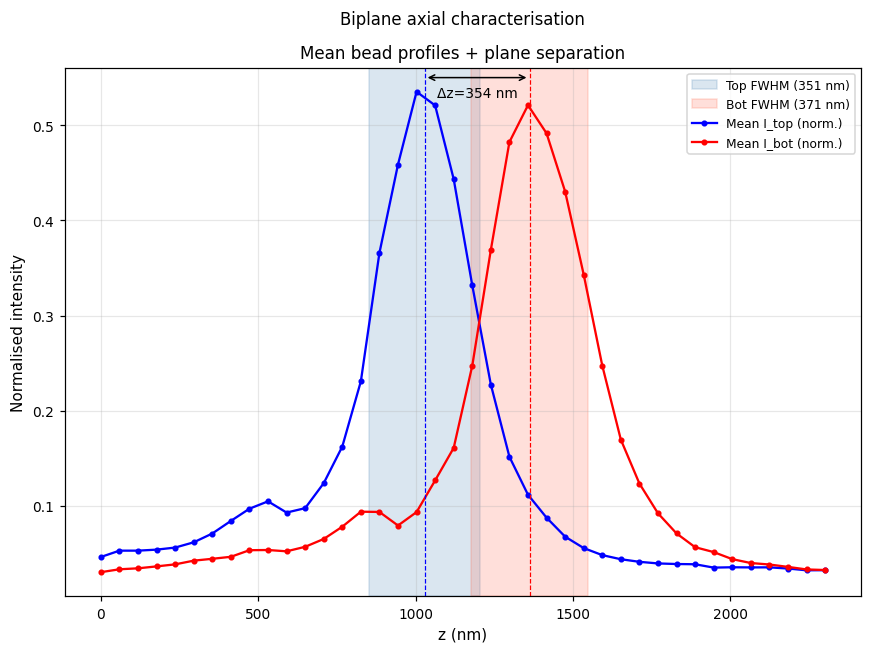


=== Part B Summary ===
  Biplane separation : 354 nm
  Axial resolution   : 361 nm FWHM
  Calibration range  : η ∈ [-0.780, 0.620]  →  z ∈ [1003, 1475] nm


In [26]:
# Claude: Measure the biplane axial separation from the peak-to-peak z offset
# of the two channels, and estimate the axial PSF FWHM by Gaussian fitting.

#DG: Calculate plane separation by looking at maximum intensity difference in top and bottom images
top_peak_slice = np.argmax(It_all, axis=1)
bot_peak_slice = np.argmax(Ib_all, axis=1)
plane_sep_nm   = np.median(bot_peak_slice - top_peak_slice) * DZ_NM

print(f"Plane separation (median over {N} beads) : {plane_sep_nm:.0f} nm")

#DG: Use curve fit to fit a Gaussian to model the PSF
def fit_z_psf(intensity_curve, z_vals):
    """Fit a 1-D Gaussian to intensity(z); return σ_z in nm."""
    peak = intensity_curve.max();  z0 = z_vals[np.argmax(intensity_curve)]
    g1d  = lambda z, A, z0, sig, B: A * np.exp(-(z-z0)**2/(2*sig**2)) + B
    try:
        popt, _ = curve_fit(g1d, z_vals, intensity_curve,
                             p0=(peak, z0, 200.0, 0.0),
                             bounds=([0, z_vals[0], 10, 0],
                                     [np.inf, z_vals[-1], 2000, np.inf]),
                             maxfev=3000)
        return abs(popt[2])
    except Exception:
        return np.nan

#DG: Fit the gaussian psf for each spot across Z slices and find FWHM
sigma_top = [fit_z_psf(It_all[i], z_nm) for i in range(N)]
sigma_bot = [fit_z_psf(Ib_all[i], z_nm) for i in range(N)]
fwhm_top  = 2.355 * np.nanmedian(sigma_top)
fwhm_bot  = 2.355 * np.nanmedian(sigma_bot)

print(f"Axial PSF FWHM  — top plane : {fwhm_top:.0f} nm")
print(f"                  bot plane : {fwhm_bot:.0f} nm")

fig, ax = plt.subplots(figsize=(8, 6))
#DG: plot the full width at half maximum as a shaded box
ax.axvspan(np.mean(top_peak_slice)*DZ_NM - fwhm_top/2,
            np.mean(top_peak_slice)*DZ_NM + fwhm_top/2,
            alpha=0.2, color='steelblue', label=f'Top FWHM ({fwhm_top:.0f} nm)')
ax.axvspan(np.mean(bot_peak_slice)*DZ_NM - fwhm_bot/2,
            np.mean(bot_peak_slice)*DZ_NM + fwhm_bot/2,
            alpha=0.2, color='tomato',    label=f'Bot FWHM ({fwhm_bot:.0f} nm)')
#DG: plot the mean intensity profile as a function of Z
ax.plot(z_nm, It_all.mean(axis=0)/It_all.max(), 'b-o', ms=3, lw=1.5, label='Mean I_top (norm.)')
ax.plot(z_nm, Ib_all.mean(axis=0)/Ib_all.max(), 'r-o', ms=3, lw=1.5, label='Mean I_bot (norm.)')
ax.axvline(np.mean(top_peak_slice)*DZ_NM, color='b', lw=0.8, ls='--')
ax.axvline(np.mean(bot_peak_slice)*DZ_NM, color='r', lw=0.8, ls='--')
#DG: Add an annotation for Delta Z
ax.annotate('', xy=(np.mean(bot_peak_slice)*DZ_NM, 0.55),
             xytext=(np.mean(top_peak_slice)*DZ_NM, 0.55),
             arrowprops=dict(arrowstyle='<->', color='k'))
ax.text((np.mean(top_peak_slice)+np.mean(bot_peak_slice))/2*DZ_NM, .53,
         f'Δz={plane_sep_nm:.0f} nm', ha='center', fontsize=9)
ax.set_xlabel('z (nm)'); ax.set_ylabel('Normalised intensity')
ax.set_title('Mean bead profiles + plane separation'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Biplane axial characterisation', x = .53)
plt.tight_layout(); plt.show()

#DG: Summarize plane separation and resolution
print(f"\n=== Part B Summary ===")
print(f"  Biplane separation : {plane_sep_nm:.0f} nm")
print(f"  Axial resolution   : {(fwhm_top+fwhm_bot)/2:.0f} nm FWHM")
print(f"  Calibration range  : η ∈ [{ETA_MIN:.3f}, {ETA_MAX:.3f}]  →  "
      f"z ∈ [{z_calib[0]:.0f}, {z_calib[-1]:.0f}] nm")


---
## c

3D particle tracking in live *E. coli*:

**Why both planes must be used for detection:**
A GEM particle closer to the bottom focal plane is bright in the bottom image
and potentially *undetectable* in the top — tracking only one plane would lose
those particles entirely.  The correct biplane approach is:

1. Detect independently in **both** planes per frame
2. Map all bottom detections into top-half pixel coordinates using the inverse of `hungarian_tform`
3. **Merge**: top and bottom detections within `MERGE_THRESH` pixels of each other → same particle; position is the intensity-weighted average in top coords
4. **Top-only** detections: particle is closer to the top focal plane; use top position, still read bottom intensity at the mapped location for η → z
5. **Bottom-only** detections: particle is closer to the bottom focal plane; map to top coords for the 2D position, read top intensity at that location for η → z
6. Track the unified detection list across frames using the Hungarian linker


In [27]:
#DG: load in the movie, saving a cropped version for Claude
#DG: Note that this isn't in the github repo because it's too big
ecoli_movie = imread("Biplane_EcoliGEM_80x80nmx30ms.tif")
# ecoli_movie_short = ecoli_movie[:51,:,:]
# imwrite("Biplane_EcoliGEM_80x80nmx30ms_short.tif", ecoli_movie_short) #DG: save a cropped version for Claude to work with

mov_top = ecoli_movie[:, 0:half_index,  :]   # plane 1  (256 rows)
mov_bot = ecoli_movie[:, half_index:,   :]   # plane 2  (256 rows)

print(f"Movie shape : {ecoli_movie.shape}  dtype {ecoli_movie.dtype}")
print(f"Each half   : {mov_top.shape}")
print(f"Duration    : {mov_top.shape[0] * DT_MS:.0f} ms  ({mov_top.shape[0]} frames × {DT_MS:.0f} ms)")

Movie shape : (1000, 512, 512)  dtype uint16
Each half   : (1000, 256, 512)
Duration    : 30000 ms  (1000 frames × 30 ms)


### C.1  Preprocessing — temporal smooth + rolling-ball background subtraction

Stage 1: temporal uniform filter (window = 3 frames)…
Stage 2: rolling-ball background (radius = 25 px) — top plane…
Stage 2: rolling-ball background (radius = 25 px) — bottom plane…
Done.


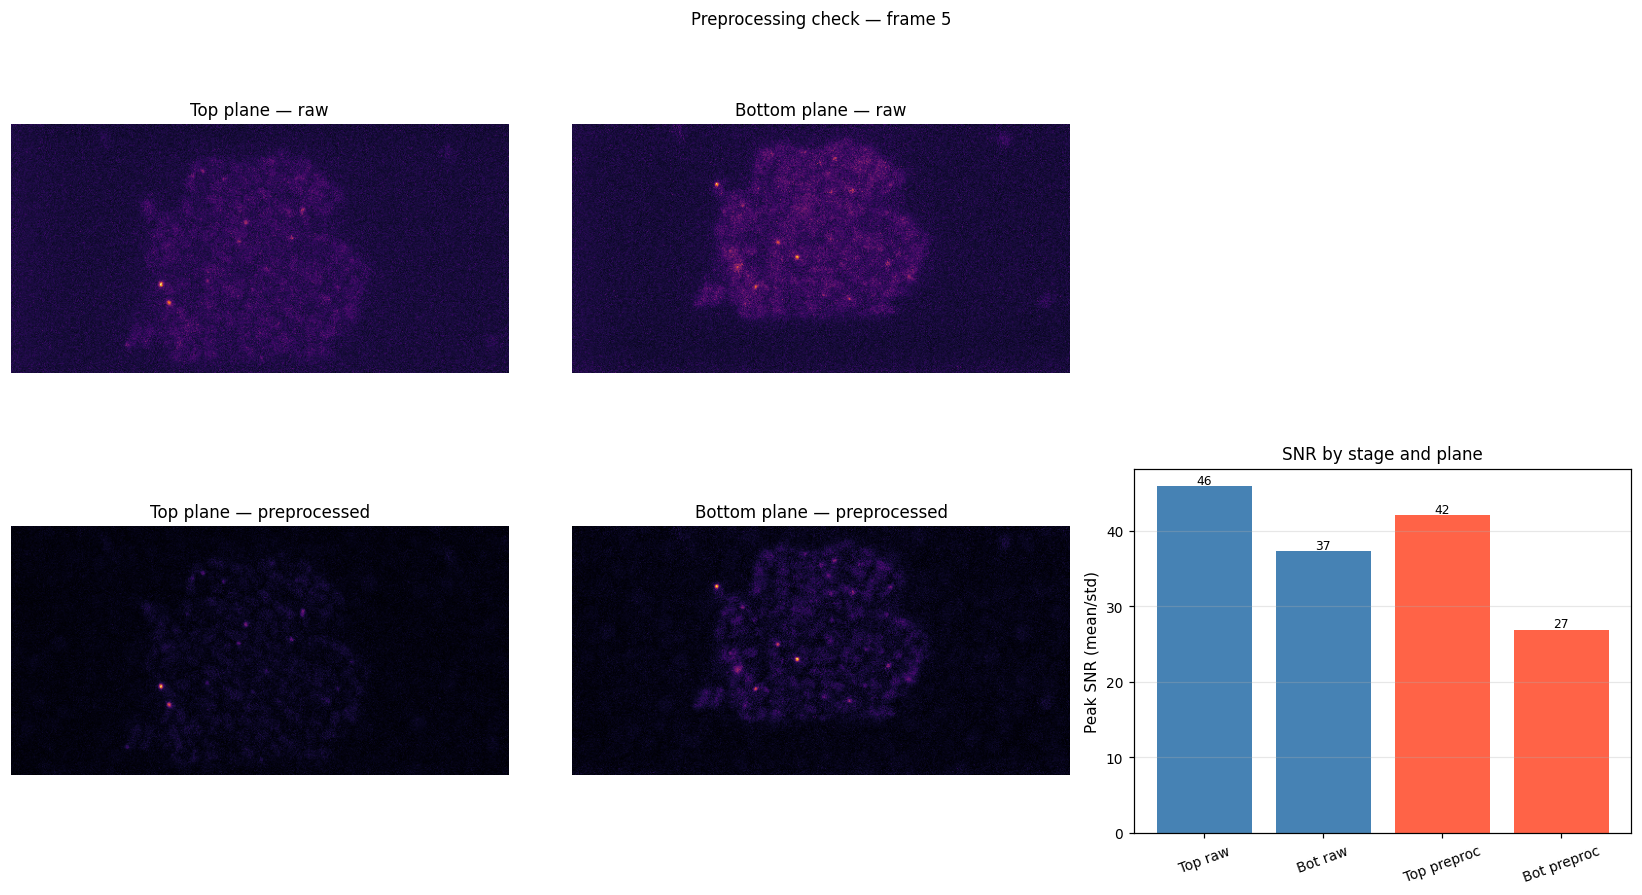

In [28]:
# Claude: Two-stage noise reduction applied to BOTH focal planes.
#
# Stage 1 — Temporal uniform filter (3-frame window = 90 ms).
#   Camera shot noise is i.i.d. in time; averaging N frames reduces it by √N.
#   GEM particles in the dense cytoplasm move < 1 px in 90 ms, so their
#   signal is not significantly blurred temporally.
#
# Stage 2 — Rolling-ball background subtraction (radius = 25 px ≈ 2 µm).
#   Removes the slowly-varying cell-body autofluorescence floor.
#   Applied per frame, per plane so each background is estimated independently.

RB_RADIUS = 25   # rolling-ball radius (pixels)  ← user-tuned value
TEMP_WIN  = 3    # temporal averaging window (frames)

#DG: Use a uniform filter across time (3 time steps) to smooth out random noise
print(f"Stage 1: temporal uniform filter (window = {TEMP_WIN} frames)…")
mov_top_tsm = uniform_filter(mov_top.astype(np.float32), size=[TEMP_WIN, 1, 1])
mov_bot_tsm = uniform_filter(mov_bot.astype(np.float32), size=[TEMP_WIN, 1, 1])

#DG: Use a rolling ball method from skimage to find the background
#DG: I set radius == 25 because that's what looked best in fiji
print(f"Stage 2: rolling-ball background (radius = {RB_RADIUS} px) — top plane…")
bg_top_rb = np.array([rolling_ball(mov_top_tsm[t], radius=RB_RADIUS)
                       for t in range(mov_top_tsm.shape[0])])
print(f"Stage 2: rolling-ball background (radius = {RB_RADIUS} px) — bottom plane…")
bg_bot_rb = np.array([rolling_ball(mov_bot_tsm[t], radius=RB_RADIUS)
                       for t in range(mov_bot_tsm.shape[0])])

#DG: Actually remove background, making sure that there are no negative values (np.maximum)
mov_top_bg = np.maximum(mov_top_tsm - bg_top_rb, 0)
mov_bot_bg = np.maximum(mov_bot_tsm - bg_bot_rb, 0)
print("Done.")

# ── Diagnostic: show both planes before/after preprocessing ──────────────────
t_demo = 5
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
#DG: save high values in the raw and background subtracted images for normalization
vmax_raw = np.percentile(np.concatenate([mov_top[t_demo].ravel(),
                                          mov_bot[t_demo].ravel()]), 99.5)
vmax_bg  = np.percentile(np.concatenate([mov_top_bg[t_demo].ravel(),
                                          mov_bot_bg[t_demo].ravel()]), 99.5)

#DG: Plot a sample frame, normalizing to 0 and highest intensity
#DG: Claude wanted to use vmin and vmax to cut the displayed intensity, but I found it easier to interpret without it
axes[0][0].imshow(mov_top[t_demo], cmap='inferno') #, vmin=0, vmax=vmax_raw)
axes[0][0].set_title(f'Top plane — raw'); axes[0][0].axis('off')
axes[0][1].imshow(mov_bot[t_demo], cmap='inferno') #, vmin=0, vmax=vmax_raw)
axes[0][1].set_title(f'Bottom plane — raw'); axes[0][1].axis('off')
axes[0][2].axis('off')

axes[1][0].imshow(mov_top_bg[t_demo], cmap='inferno') #, vmin=0, vmax=vmax_bg)
axes[1][0].set_title(f'Top plane — preprocessed'); axes[1][0].axis('off')
axes[1][1].imshow(mov_bot_bg[t_demo], cmap='inferno') #, vmin=0, vmax=vmax_bg)
axes[1][1].set_title(f'Bottom plane — preprocessed'); axes[1][1].axis('off')

# SNR comparison
#DG: Calculate SNR by mean / std and compare on a bar chart
snrs = {'Top raw': mov_top[t_demo].max()/mov_top[t_demo].std(),
        'Bot raw': mov_bot[t_demo].max()/mov_bot[t_demo].std(),
        'Top preproc': mov_top_bg[t_demo].max()/mov_top_bg[t_demo].std(),
        'Bot preproc': mov_bot_bg[t_demo].max()/mov_bot_bg[t_demo].std()}
axes[1][2].bar(list(snrs.keys()), list(snrs.values()),
                color=['steelblue','steelblue','tomato','tomato'])
axes[1][2].set_ylabel('Peak SNR (mean/std)'); axes[1][2].set_title('SNR by stage and plane')
axes[1][2].grid(axis='y', alpha=0.3)
for i,(k,v) in enumerate(snrs.items()):
    axes[1][2].text(i, v+0.3, f'{v:.0f}', ha='center', fontsize=8)
axes[1][2].tick_params(axis='x', labelrotation=20)

plt.suptitle(f'Preprocessing check — frame {t_demo}', y=1.01)
plt.tight_layout(); plt.show()


### C.2  Dual-plane detection and z-estimation per frame

Processing all frames (both planes)…

Per-frame detections:
  Top-only approach  : min=14  max=26  mean=20.1
  Bot-only approach  : min=24  max=40  mean=30.7
  Dual-plane (merged): min=34  max=55  mean=43.0
  Fraction with z    : 100%


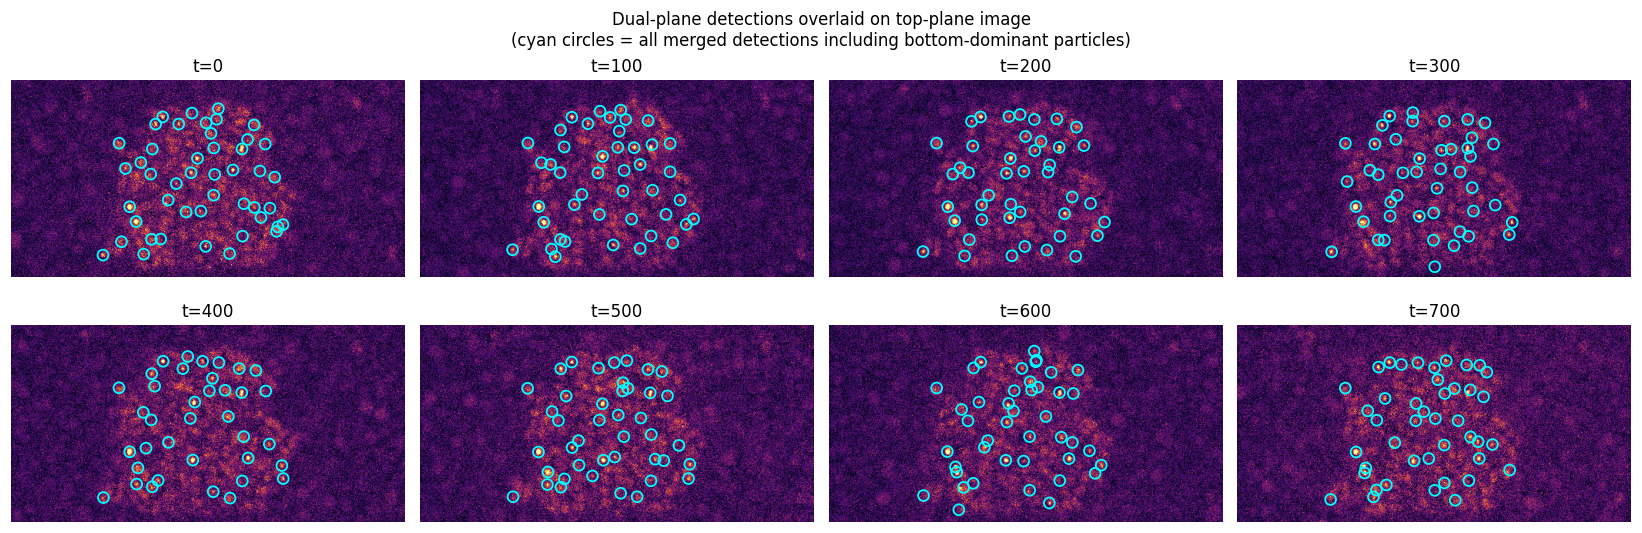

In [29]:
# Claude: LoG spot detection runs on BOTH preprocessed planes.
# All positions are ultimately expressed in top-half pixel coordinates
# so that the tracking linker operates in a single consistent space.

LOG_SIGMA     = 1.5   # pixels — matches ~2-pixel GEM PSF radius
DETECT_NSIGMA = 5.0   # detection threshold: mean + N × std of LoG response
MIN_DIST_PX   = 5     # minimum centre-to-centre distance between peaks
EDGE_MARGIN   = 8     # ignore peaks within this many pixels of the border
MERGE_THRESH_PX = 10  # top and bottom detections within this distance = same particle

# Scalar background estimates for intensity readout from the RAW frames
# (we use raw frames for η because the background-subtraction pipeline
#  may clip differently in each plane; a fixed scalar offset is fairer)
BG_TOP = float(np.percentile(mov_top, 5))
BG_BOT = float(np.percentile(mov_bot, 5))

#DG: helper function to find bright spots in each frame
#    basically the same as from part A, but written by Claude this time
#    has a bit more dials to tune, but it's the same LoG into max filter into gaussian estimation 
def detect_spots_log(img, n_sigma=DETECT_NSIGMA,
                      min_dist=MIN_DIST_PX, margin=EDGE_MARGIN):
    """
    Find bright spots in a single preprocessed frame via LoG + local-max.
    Returns (N, 2) float array of sub-pixel [y, x] centroids.
    """
    log  = -ndimage.gaussian_laplace(img, sigma=LOG_SIGMA)
    thr  = log.mean() + n_sigma * log.std()
    maxf = ndimage.maximum_filter(log, size=2 * min_dist + 1)
    pks  = np.argwhere((log == maxf) & (log > thr))
    inside = ((pks[:, 0] > margin) & (pks[:, 0] < img.shape[0] - margin) &
              (pks[:, 1] > margin) & (pks[:, 1] < img.shape[1] - margin))
    pks = pks[inside]
    refined = []
    for py, px in pks:
        r = fit_gaussian_2d(img, int(py), int(px), radius=4)
        refined.append([r['y'], r['x']] if r else [float(py), float(px)])
    return np.array(refined) if refined else np.empty((0, 2))

#DG: Get a square around a spot
def read_intensity(img, y, x, radius=3):
    """Peak intensity in a small window; returns 0 if out of bounds."""
    yi, xi = int(round(y)), int(round(x))
    if yi < 0 or yi >= img.shape[0] or xi < 0 or xi >= img.shape[1]:
        return 0.0
    return float(img[max(0, yi-radius) : min(img.shape[0], yi+radius+1),
                      max(0, xi-radius) : min(img.shape[1], xi+radius+1)].max())

#DG: Claude was at first only looking at the top frame, so I prompted it to look at both
#    This function considers spots in both or a single focal plane
def process_frame_dual(t):
    """
    Detect GEM particles in frame *t* using both focal planes.

    Returns an (N, 3) array: [y_top_px, x_top_px, z_nm].
    All 2D positions are expressed in top-half pixel coordinates.
    z_nm is NaN when η falls outside the calibrated range.

    Detection categories
    --------------------
    'both'     : detected in top AND bottom → intensity-weighted 2D position
    'top_only' : detected only in top       → top position; bottom read at mapped loc
    'bot_only' : detected only in bottom    → position mapped to top coords;
                                              top read at that mapped location
    """
    #DG: First get the spots from both the top and bottom frame
    top_dets = detect_spots_log(mov_top_bg[t])
    bot_dets = detect_spots_log(mov_bot_bg[t])

    #DG: Align coordinate spaces with the affine transform
    # Map all bottom detections into top-half coordinate space for merging
    bot_in_top = (bot_yx_to_top_yx(bot_dets) if len(bot_dets) > 0
                  else np.empty((0, 2)))

    detections = []
    used_top   = set()
    used_bot   = set()

    # ── Merge nearby top & bottom detections (same particle in both planes) ──
    #DG: frame has spots in both top and bottom
    if len(top_dets) > 0 and len(bot_in_top) > 0:
        #DG: calculate Euclidean distance between spots in the top and bottom planes
        #DG: This is to avoid counting the same one twice if it's within a threshold
        #DG: Use linear_sum_assignment to match
        D = np.sqrt(((top_dets[:, None, :] - bot_in_top[None, :, :])**2).sum(axis=2))
        ri, ci = linear_sum_assignment(D)
        for r, c in zip(ri, ci):
            #DG: if the spots are too close, don't count them
            if D[r, c] > MERGE_THRESH_PX:
                continue
            #DG: otherwise, get their coordinates
            ty, tx = top_dets[r];  by, bx = bot_dets[c]
            #DG: and use those to get the intensity in the local area
            #DG: Important! This uses the raw image! No background subtraction
            It = max(read_intensity(mov_top[t], ty, tx) - BG_TOP, 1.)
            Ib = max(read_intensity(mov_bot[t], by, bx) - BG_BOT, 1.)
            # Intensity-weighted 2D centroid in top coords
            #DG: Use both plane detections to refine the positioning of the spot
            y2d = (It * ty  + Ib * bot_in_top[c, 0]) / (It + Ib)
            x2d = (It * tx  + Ib * bot_in_top[c, 1]) / (It + Ib)
            #DG: Using the defocus parameter to get Z
            #DG: I also added an offset so that the bottom plane is Z == 0
            eta = (It - Ib) / (It + Ib)
            detections.append([y2d, x2d, eta_to_z(eta, offset = True)])
            used_top.add(r);  used_bot.add(c)

    # ── Top-only: particle near top focal plane, dim/absent in bottom ────────
    for i, (ty, tx) in enumerate(top_dets):
        #DG: check that we didn't already work with this spot in the matched part above
        if i in used_top:
            continue
        #DG: if no, do basically the same thing as before
        It = max(read_intensity(mov_top[t], ty, tx) - BG_TOP, 1.)
        # Read bottom at the corresponding mapped location even without a detection
        #DG: get the bottom intensity to be able to estimate a Z height
        bp = top_yx_to_bot_yx(np.array([[ty, tx]]))[0]
        Ib = max(read_intensity(mov_bot[t], bp[0], bp[1]) - BG_BOT, 1.)
        eta = (It - Ib) / (It + Ib)
        detections.append([ty, tx, eta_to_z(eta, offset = True)])

    # ── Bottom-only: particle near bottom focal plane, dim/absent in top ─────
    #DG: same logic as for top only
    for j, (by, bx) in enumerate(bot_dets):
        if j in used_bot:
            continue
        tp = bot_in_top[j]          # position mapped to top coordinate space
        It = max(read_intensity(mov_top[t], tp[0], tp[1]) - BG_TOP, 1.)
        Ib = max(read_intensity(mov_bot[t], by, bx)        - BG_BOT, 1.)
        eta = (It - Ib) / (It + Ib)
        detections.append([tp[0], tp[1], eta_to_z(eta, offset = True)])

    return np.array(detections) if detections else np.empty((0, 3))


# ── Run on all frames ─────────────────────────────────────────────────────────
print("Processing all frames (both planes)…")
all_dets_dual = [process_frame_dual(t) for t in range(mov_top_bg.shape[0])]

#DG: count number of spots per frame 
#DG: also check that every spot got a valid Z value
n_per_frame  = [len(d) for d in all_dets_dual]
n_z_per_frame = [int(np.sum(~np.isnan(d[:, 2]))) if len(d) else 0
                  for d in all_dets_dual]

# Compare with top-only baseline
#DG: This is from earlier testing
n_top_only = [len(detect_spots_log(mov_top_bg[t]))   for t in range(50)]
n_bot_only = [len(detect_spots_log(mov_bot_bg[t]))   for t in range(50)]

print(f"\nPer-frame detections:")
print(f"  Top-only approach  : min={min(n_top_only)}  max={max(n_top_only)}  "
      f"mean={np.mean(n_top_only):.1f}")
print(f"  Bot-only approach  : min={min(n_bot_only)}  max={max(n_bot_only)}  "
      f"mean={np.mean(n_bot_only):.1f}")
print(f"  Dual-plane (merged): min={min(n_per_frame)}  max={max(n_per_frame)}  "
      f"mean={np.mean(n_per_frame):.1f}")
print(f"  Fraction with z    : {np.mean(n_z_per_frame)/np.mean(n_per_frame)*100:.0f}%")

# ── Visualise detections in a selection of frames ─────────────────────────────
#DG: Plot every 100 frames to show a sampling of found spots
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for idx, ax in enumerate(axes.flat):
    t = idx * 100
    # Show top-plane image with all detections overlaid
    ax.imshow(mov_top_bg[t], cmap='inferno',
               vmin = 0, vmax=np.percentile(mov_top_bg[t], 99.9))
    pts = all_dets_dual[t]
    if len(pts):
        ax.scatter(pts[:, 1], pts[:, 0], s=50,
                   facecolors='none', edgecolors='cyan', linewidths=1.2)
    ax.set_title(f't={t}')
    ax.axis('off')

fig.subplots_adjust(hspace=-.6)
plt.suptitle('Dual-plane detections overlaid on top-plane image\n'
              '(cyan circles = all merged detections including bottom-dominant particles)',
              y=.8)
plt.tight_layout(); plt.show()


### C.3  Link detections into tracks

In [30]:
# Claude: Two-phase linking strategy to handle GEMs that briefly drop below the
# detection threshold.
#
# Phase 1 — frame-by-frame Hungarian linker with gap-closing.
#   MAX_GAP_FRAMES = 5 (was 2).  A particle can be invisible for up to 5 frames
#   (150 ms) and still be reconnected to the same track.  Raising this beyond ~5
#   risks linking across genuine track ends, but 5 is conservative enough given
#   that GEMs are confined inside bacteria.
#
# Phase 2 — post-hoc track stitching.
#   After Phase 1, some tracks that belong to the same particle are still split
#   because the dropout lasted longer than MAX_GAP.  We search for pairs of tracks
#   (A ends, B starts) where:
#     • the time gap is ≤ STITCH_GAP_FRAMES (10 frames = 300 ms)
#     • the spatial distance between A's last position and B's first position is
#       ≤ STITCH_RADIUS_NM (400 nm ≈ 5 px)
#   Only ~16 out of ~2000 candidate pairs satisfy both constraints on a 50-frame
#   clip, so the radius is tight enough to make false stitches negligible.
#   We use a greedy assignment (sort by distance, accept each stitch once) to
#   avoid cycles.

MAX_JUMP_PX       = 10                    # max frame-to-frame displacement (px)
MAX_JUMP_NM       = MAX_JUMP_PX * DXY_NM
MAX_GAP_FRAMES    = 5                     # frames a track may be invisible in linker
MIN_TRACK_LEN     = 5                     # minimum frames to keep a track

STITCH_GAP_FRAMES = 10                    # max frame gap for post-hoc stitching
STITCH_RADIUS_NM  = 400.                  # max spatial distance for stitching (nm)

#DG: this cell is pretty complicated and I definitely do not fully understand it

def link_detections(all_frame_dets, max_jump_nm=MAX_JUMP_NM,
                     max_gap=MAX_GAP_FRAMES):
    """
    Phase 1: frame-by-frame nearest-neighbour Hungarian linker with gap-closing.
    Returns a list of track dicts with keys 'frames', 'y_nm', 'x_nm', 'z_nm'.
    """
    tracks = [];  active = []

    for t, dets in enumerate(all_frame_dets):
        if len(dets) == 0:
            #DG: if there's no detections, get the data from the previous frame, but only if it's been less than 5 frames since previous data
            active = [(f, p, i) for f, p, i in active if t - f <= max_gap]
            continue
        #DG: get the positions of the spots
        det_yx_nm = dets[:, :2] * DXY_NM

        if not active:
            for d in dets:
                #DG: add tracks and keep track of the active frame
                tracks.append({'frames': [t], 'y_nm': [d[0]*DXY_NM],
                                'x_nm': [d[1]*DXY_NM], 'z_nm': [d[2]]})
                active.append((t, d[:2]*DXY_NM, len(tracks)-1))
            continue

        #DG: build one to one matching between active frame and previous frame
        act_yx = np.array([p for _, p, _ in active])
        D = spatial.distance.cdist(act_yx, det_yx_nm)
        ri, ci = linear_sum_assignment(D)
        matched_active = set();  matched_dets = set()

        #DG: go through and add new track data
        for r, c in zip(ri, ci):
            #DG: but only if the new spot is close
            if D[r, c] < max_jump_nm:
                ti = active[r][2]
                tracks[ti]['frames'].append(t)
                tracks[ti]['y_nm'].append(dets[c, 0] * DXY_NM)
                tracks[ti]['x_nm'].append(dets[c, 1] * DXY_NM)
                tracks[ti]['z_nm'].append(dets[c, 2])
                matched_active.add(r);  matched_dets.add(c)

        new_active = []
        for r, (f, p, i) in enumerate(active):
            #DG: if you hit a match for a spot, add that to the next iterations previous frame
            if r in matched_active:
                ri_list = list(ri)
                new_active.append((t, det_yx_nm[ci[ri_list.index(r)]], i))
            #DG: keep going from the previous one if there were no matches and it hasn't been 5 steps
            elif t - f <= max_gap:
                new_active.append((f, p, i))

        for c, d in enumerate(dets):
            #DG: if you didn't match, that means it's a new track and you need to make a new record of that
            if c not in matched_dets:
                tracks.append({'frames': [t], 'y_nm': [d[0]*DXY_NM],
                                'x_nm': [d[1]*DXY_NM], 'z_nm': [d[2]]})
                new_active.append((t, d[:2]*DXY_NM, len(tracks)-1))

        active = new_active

    #DG: reorganize track data as an array
    for tr in tracks:
        for k in ('frames', 'y_nm', 'x_nm', 'z_nm'):
            tr[k] = np.array(tr[k])
    return tracks


def stitch_tracks(tracks, stitch_gap=STITCH_GAP_FRAMES,
                   stitch_radius=STITCH_RADIUS_NM):
    """
    Phase 2: post-hoc gap stitching.
    For every ordered pair (A, B) where A ends before B starts, within the
    time and space thresholds, greedily merge B into A (shortest distance first).
    Each track endpoint and start point is used at most once.
    """
    n = len(tracks)
    # Build candidate (distance, gap, i, j) list
    candidates = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            #DG: check for gaps between tracks if they start and end kinda close to each other in time
            gap = int(tracks[j]['frames'][0]) - int(tracks[i]['frames'][-1])
            if gap < 1 or gap > stitch_gap:
                continue
            dy = tracks[i]['y_nm'][-1] - tracks[j]['y_nm'][0]
            dx = tracks[i]['x_nm'][-1] - tracks[j]['x_nm'][0]
            #DG: and close to each other in space
            dist = np.sqrt(dy**2 + dx**2)
            if dist <= stitch_radius:
                candidates.append((dist, gap, i, j))

    candidates.sort()   # closest pairs first

    # Union-find to track merged identities
    parent = list(range(n))
    #DG: this is some algorithm that I do not understand
    def root(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]; i = parent[i]
        return i

    alive        = [True] * n
    used_as_tail = set()
    used_as_head = set()
    n_stitched   = 0

    #DG: I think this is going through the possible track matches and testing few things
    for dist, gap, i, j in candidates:
        ri, rj = root(i), root(j)
        if ri == rj:
            #    Do the tracks start in the same place?
            continue                          # already the same track
        if i in used_as_tail or j in used_as_head:
            #    Has this track ending / beginning already matched with another track?
            continue                          # endpoint already consumed
        # Concatenate j into ri
        #DG: if above checks passed, then the starts and ends are close to each other and not aligned with another track
        #DG: so go ahead and add them together
        tracks[ri]['frames'] = np.concatenate([tracks[ri]['frames'], tracks[rj]['frames']])
        tracks[ri]['y_nm']   = np.concatenate([tracks[ri]['y_nm'],   tracks[rj]['y_nm']])
        tracks[ri]['x_nm']   = np.concatenate([tracks[ri]['x_nm'],   tracks[rj]['x_nm']])
        tracks[ri]['z_nm']   = np.concatenate([tracks[ri]['z_nm'],   tracks[rj]['z_nm']])
        parent[rj]  = ri
        alive[rj]   = False
        used_as_tail.add(i)
        used_as_head.add(j)
        n_stitched += 1

    surviving = [tr for idx, tr in enumerate(tracks) if alive[idx]]
    return surviving, n_stitched


# ── Run both phases ───────────────────────────────────────────────────────────
tracks_raw    = link_detections(all_dets_dual)
tracks_stitched, n_stitched = stitch_tracks(tracks_raw)
tracks_long   = [tr for tr in tracks_stitched if len(tr['frames']) >= MIN_TRACK_LEN]

lengths  = np.array([len(tr['frames']) for tr in tracks_long])
frac_z   = [np.sum(~np.isnan(tr['z_nm'])) / len(tr['frames']) for tr in tracks_long]

print(f"Phase 1 (linker, gap≤{MAX_GAP_FRAMES})  : {len(tracks_raw)} raw tracks")
print(f"Phase 2 (stitcher)                   : {n_stitched} track pairs merged")
print(f"Final tracks ≥ {MIN_TRACK_LEN} frames         : {len(tracks_long)}")
print(f"Track length  median / max           : {np.median(lengths):.0f} / {lengths.max()} frames")
print(f"Frames with valid z                  : {np.mean(frac_z)*100:.0f}%")


Phase 1 (linker, gap≤5)  : 2662 raw tracks
Phase 2 (stitcher)                   : 488 track pairs merged
Final tracks ≥ 5 frames         : 532
Track length  median / max           : 14 / 1000 frames
Frames with valid z                  : 100%


### C.4  2-D track overlay and quality-control figures

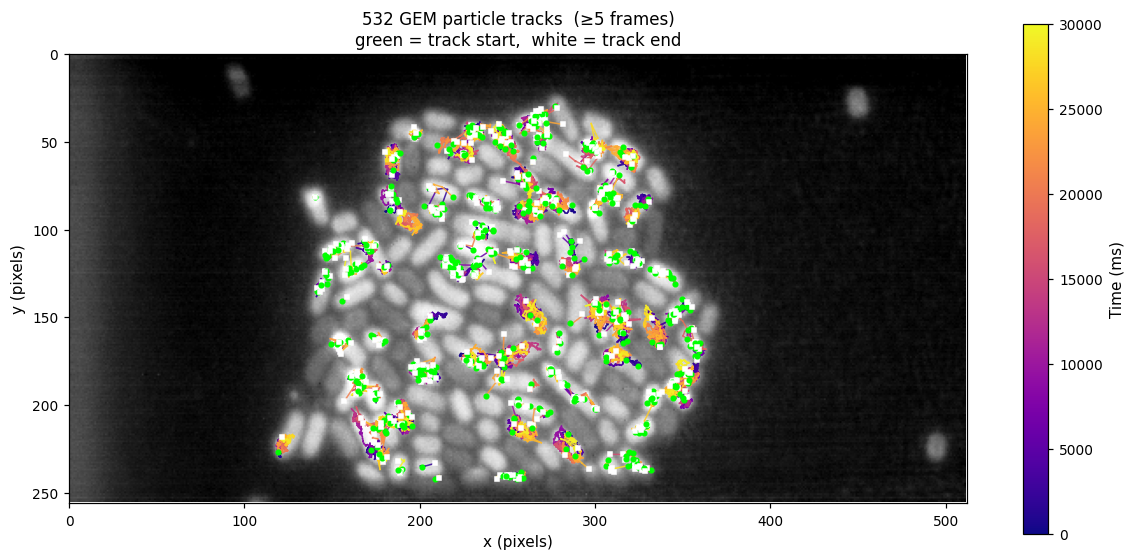

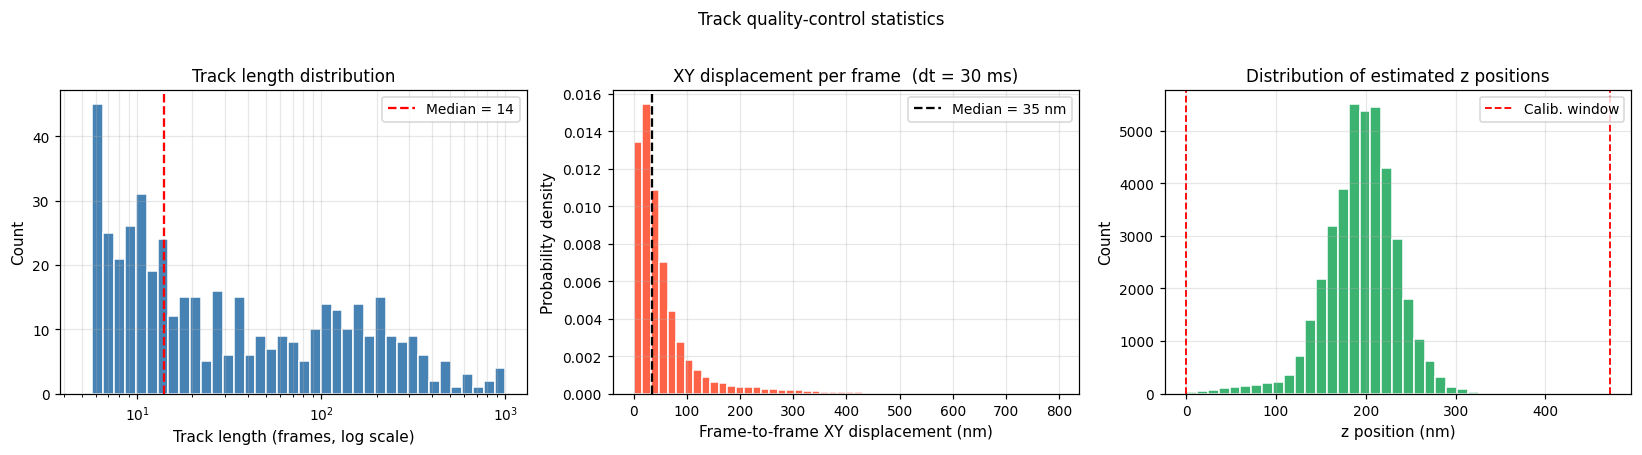

In [31]:
# Claude: Overlay all long tracks on the temporal mean of the top-plane movie.
# The mean image shows where the cells are (their autofluorescence is static
# while the GEM particles average out).  Tracks are colour-coded by time.

#DG: make an image that averages the whole movie
mean_img = mov_top.mean(axis=0)   # (256, 512) — static cell autofluorescence

fig, ax = plt.subplots(figsize=(11, 8))
#DG: plot the mean image as a baseline
ax.imshow(mean_img, cmap='Greys_r',
           vmin=np.percentile(mean_img, 5),
           vmax=np.percentile(mean_img, 99.5))

#DG: plot each track with the start and end points labeled, and the track colored by time step
cmap_t = plt.get_cmap('plasma')
for tr in tracks_long:
    xs     = tr['x_nm'] / DXY_NM
    ys     = tr['y_nm'] / DXY_NM
    frames = tr['frames']
    for j in range(len(frames) - 1):
        #DG: this does the coloring by time
        c = cmap_t(frames[j] / mov_top.shape[0])
        ax.plot(xs[j:j+2], ys[j:j+2], '-', color=c, lw=1.0, alpha=0.85)
    ax.plot(xs[0],  ys[0],  'o', color='lime',  ms=3, zorder=5)
    ax.plot(xs[-1], ys[-1], 's', color='white', ms=3, zorder=5)

sm = plt.cm.ScalarMappable(cmap='plasma',
                             norm=Normalize(0, mov_top.shape[0] * DT_MS))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Time (ms)', shrink=0.6)
ax.set_title(f'{len(tracks_long)} GEM particle tracks  (≥{MIN_TRACK_LEN} frames)\n'
              f'green = track start,  white = track end')
ax.set_xlabel('x (pixels)');  ax.set_ylabel('y (pixels)')
ax.set_xlim(0, mean_img.shape[1]);  ax.set_ylim(mean_img.shape[0], 0)
plt.tight_layout();  plt.show()

# ── QC histograms ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
#DG: plot histogram of track lenghts on a log scale to easily visualize
ax.hist(lengths, bins=np.logspace(np.log10(MIN_TRACK_LEN), np.log10(lengths.max() + 1), 40),
         color='steelblue', edgecolor='white')
ax.set_xscale('log')
ax.axvline(np.median(lengths), color='r', lw=1.5, ls='--',
            label=f'Median = {np.median(lengths):.0f}')
ax.set_xlabel('Track length (frames, log scale)');  ax.set_ylabel('Count')
ax.set_title('Track length distribution');  ax.legend();  ax.grid(alpha=0.3, which = 'both')

ax = axes[1]
#DG: plot histogram of average XY displacement
displacements = np.concatenate([
    np.sqrt(np.diff(tr['x_nm'])**2 + np.diff(tr['y_nm'])**2)
    for tr in tracks_long])
ax.hist(displacements, bins=50, color='tomato', edgecolor='white', density=True)
ax.axvline(np.median(displacements), color='k', lw=1.5, ls='--',
            label=f'Median = {np.median(displacements):.0f} nm')
ax.set_xlabel('Frame-to-frame XY displacement (nm)')
ax.set_ylabel('Probability density')
ax.set_title(f'XY displacement per frame  (dt = {DT_MS:.0f} ms)')
ax.legend();  ax.grid(alpha=0.3)

ax = axes[2]
#DG: plot estimated Z position
all_z = np.concatenate([tr['z_nm'][~np.isnan(tr['z_nm'])]
                          for tr in tracks_long if np.any(~np.isnan(tr['z_nm']))])
ax.hist(all_z, bins=30, color='mediumseagreen', edgecolor='white')
ax.axvline(z_calib[0]-1003,  color='r', ls='--', lw=1.2, label='Calib. window')
ax.axvline(z_calib[-1]-1003, color='r', ls='--', lw=1.2)
ax.set_xlabel('z position (nm)');  ax.set_ylabel('Count')
ax.set_title('Distribution of estimated z positions')
ax.legend();  ax.grid(alpha=0.3)

plt.suptitle('Track quality-control statistics', y=1.02)
plt.tight_layout();  plt.show()


### C.5  3-D trajectories

Tracks with ≥40% valid z : 54


/tmp/ipykernel_13901/1878481531.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=8);  ax2.grid(alpha=0.3)


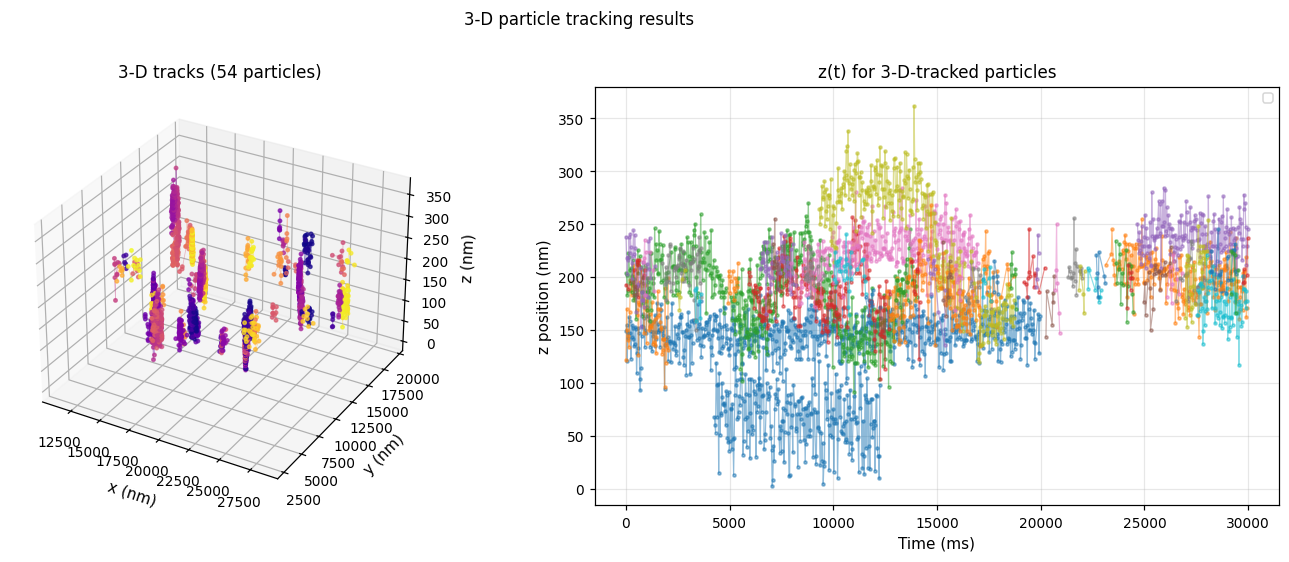


=== Part C Summary ===
  Movie frames analysed       : 1000  (30000 ms)
  Detection method            : dual-plane LoG + intensity-weighted merge
  Particles tracked (≥5 fr)  : 532
  With 3-D z data (≥40%)  : 54
  Track length  median / max  : 14 / 1000 frames
  Median XY displacement      : 35 nm / frame


In [36]:
# Claude: 3-D track visualisation for particles with enough z data.

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

min_z_frac = 0.4
#DG: subset to every 10th track
#DG: this also only keeps tracks that have enough Z information, but that's all of them in my code
tracks_3d  = [tr for tr in tracks_long[::10]
               if np.sum(~np.isnan(tr['z_nm'])) / len(tr['frames']) >= min_z_frac]
print(f"Tracks with ≥{min_z_frac*100:.0f}% valid z : {len(tracks_3d)}")

fig = plt.figure(figsize=(13, 5))

ax3 = fig.add_subplot(121, projection='3d')
for tr in tracks_3d:
    good = ~np.isnan(tr['z_nm'])
    if good.sum() < 2: continue
    cols = cmap_t(tr['frames'][good] / mov_top.shape[0])
    #DG: plot the tracks in 3D
    ax3.scatter(tr['x_nm'][good], tr['y_nm'][good], tr['z_nm'][good],
                c=cols, s=5, alpha=0.7)
    ax3.plot(tr['x_nm'][good], tr['y_nm'][good], tr['z_nm'][good],
             '-', color=cols[0], lw=0.5, alpha=0.4)
ax3.set_xlabel('x (nm)');  ax3.set_ylabel('y (nm)');  ax3.set_zlabel('z (nm)')
ax3.set_title(f'3-D tracks ({len(tracks_3d)} particles)')

#DG: plot Z over time for each track
ax2 = fig.add_subplot(122)
for tr in tracks_3d:
    valid = ~np.isnan(tr['z_nm'])
    if valid.sum() < 2: continue
    ax2.plot(tr['frames'][valid] * DT_MS, tr['z_nm'][valid],
             '-o', ms=2, lw=0.8, alpha=0.5)
# ax2.axhline(z_calib[0],  color='r', ls='--', lw=0.8, label='Calib. window')
# ax2.axhline(z_calib[-1], color='r', ls='--', lw=0.8)
ax2.set_xlabel('Time (ms)');  ax2.set_ylabel('z position (nm)')
ax2.set_title('z(t) for 3-D-tracked particles')
ax2.legend(fontsize=8);  ax2.grid(alpha=0.3)

plt.suptitle('3-D particle tracking results', y=1.01)
plt.tight_layout();  plt.show()

print(f"\n=== Part C Summary ===")
print(f"  Movie frames analysed       : {mov_top.shape[0]}  ({mov_top.shape[0]*DT_MS:.0f} ms)")
print(f"  Detection method            : dual-plane LoG + intensity-weighted merge")
print(f"  Particles tracked (≥{MIN_TRACK_LEN} fr)  : {len(tracks_long)}")
print(f"  With 3-D z data (≥{min_z_frac:.0%})  : {len(tracks_3d)}")
print(f"  Track length  median / max  : {int(np.median(lengths))} / {lengths.max()} frames")
print(f"  Median XY displacement      : {np.median(displacements):.0f} nm / frame")


In [35]:
np.unique(lengths, return_counts = True)

(array([   5,    6,    7,    8,    9,   10,   11,   12,   13,   14,   15,
          16,   17,   18,   19,   20,   21,   22,   23,   24,   26,   27,
          28,   29,   30,   31,   32,   33,   34,   35,   36,   37,   38,
          39,   40,   41,   42,   43,   45,   46,   47,   48,   49,   50,
          51,   52,   54,   55,   56,   60,   61,   62,   63,   64,   65,
          67,   68,   69,   71,   72,   73,   76,   80,   81,   83,   85,
          88,   89,   92,   95,   97,   98,   99,  100,  101,  105,  106,
         107,  108,  109,  112,  113,  115,  118,  119,  121,  122,  125,
         126,  128,  129,  130,  135,  136,  138,  141,  145,  148,  149,
         155,  156,  157,  159,  160,  164,  166,  167,  168,  169,  171,
         175,  176,  178,  179,  180,  181,  185,  199,  200,  201,  202,
         203,  207,  208,  212,  214,  215,  217,  219,  224,  227,  228,
         229,  230,  235,  236,  239,  262,  267,  277,  283,  285,  286,
         292,  299,  303,  304,  305, 

Overall, this notebook found 532 tracked particles with a huge variety of durations and lenghts. Some (<5) stayed for the entire time, while most tracks were on the order of 10 time points. Judging by the overlay on the cells, it seems that a lot of tracks were going in and out from the same cells, so there is probably more to be done to have continuous tracking of the GEMs. There are also a few tracks that cross between cells which should not be happening, but this is a minority. Additionally, the majority of tracks and predicted Z heights are right in the middle of the two planes. I am not sure if this is a real result or if this is a computational artifact. By looking at the z(t) graph, we can see that the program did identify spots that stay at various height levels, and ones that move between them at random.